# Plotting notebook
This notebook provides the code to reproduce the figures in the paper

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['font.family'] = 'times new roman'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['axes.grid.axis'] = 'y' 
plt.rcParams['axes.axisbelow'] = True

In [4]:
cpe = pd.read_csv('data/output/C2P.csv')
pce = pd.read_csv('data/output/P2C.csv')

In [ ]:
foodb = pd.read_csv('data/output/foodb.csv')

# Distributions

## Comp2Prot

In [22]:
densities = {}

clean = cpe.loc[cpe['ave_pchembl'] != 'Sources do not provide activity data']
clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)
for thresh in [6, 8]:
    counts = clean.loc[(clean['ave_pchembl'] > thresh), 'DB_ID'].value_counts()
    counts_df = counts.reset_index()
    counts_df.columns = ['DB_ID', 'counts']
    densities[f'CPIExtract pChEMBL > {thresh}'] = counts_df.counts
for thresh in [6, 8]:
    db = clean.loc[(clean['ave_pchembl'] > thresh) & (clean['drugbank'] == 1), 'DB_ID'].value_counts()
    counts_db = db.reset_index()
    counts_db.columns = ['DB_ID', 'counts']
    densities[f'DB pChEMBL > {thresh}'] = counts_db.counts


C:\Users\andre\AppData\Local\Temp\ipykernel_6020\2772799162.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)


CPIExtract pChEMBL > 6: 4.981051507872965
CPIExtract pChEMBL > 8: 2.366213151927438
DB pChEMBL > 6: 1.7875422501207145
DB pChEMBL > 8: 1.5295454545454545


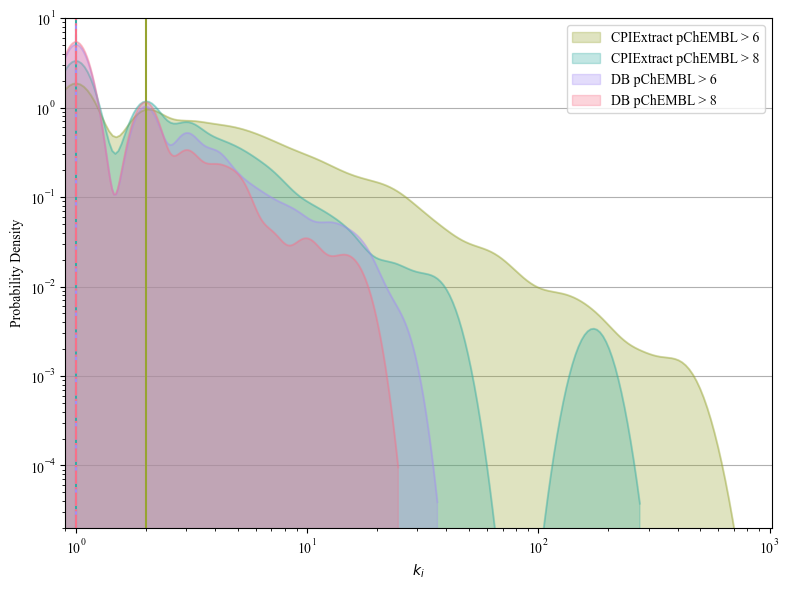

In [23]:
import matplotlib.patches as mpatches
# Initialize color palette
lenn = len(densities)
palette = sns.color_palette("husl", lenn)
plt.figure(figsize=(8,6))
# Plot KDE plots for each category in densities
for i, (label, data) in enumerate(densities.items()):
    # if label[:2] == 'DB':
    #     sns.kdeplot(data, label=label, alpha=0.8, fill=True, color='gray', log_scale=[True, True])
    # else:    
    kde = sns.kdeplot(data, label=label,fill=None, alpha=0.3, color=palette[(i+1)%lenn], 
                log_scale=[True, True])
    
    x, y = kde.get_lines()[-1].get_data()
    # Use fill_between to fill the area under the curve
    plt.fill_between(x, y, 0.0000001, color=palette[(i+1)%lenn], alpha=0.3)
    # Calculate median
    median_value = data.median()
    print(f"{label}: {data.mean()}")
    # last two median lines are overlapping, making one a continuous line
    lines = ['-', '-', '--', 'dashdot']

    plt.axvline(x=median_value, linestyle=lines[i], color=palette[(i+1)%lenn])

legend_handles = [mpatches.Patch(color=palette[(i + 1) % lenn], alpha=0.3, label=label) for i, label in enumerate(densities.keys())]

# Set labels and title
plt.xlabel('$k_i$')
plt.ylabel('Probability Density')
# Plot mean line
plt.xlim(0.9)
plt.ylim(2*10e-6, 10)  # Adjust the limits according to your preference
# Show legend
plt.legend(handles=legend_handles)
# plt.title('Degree k Probability Distribution for C-PIE and DB')
plt.tight_layout()
# Show the plot
plt.show()

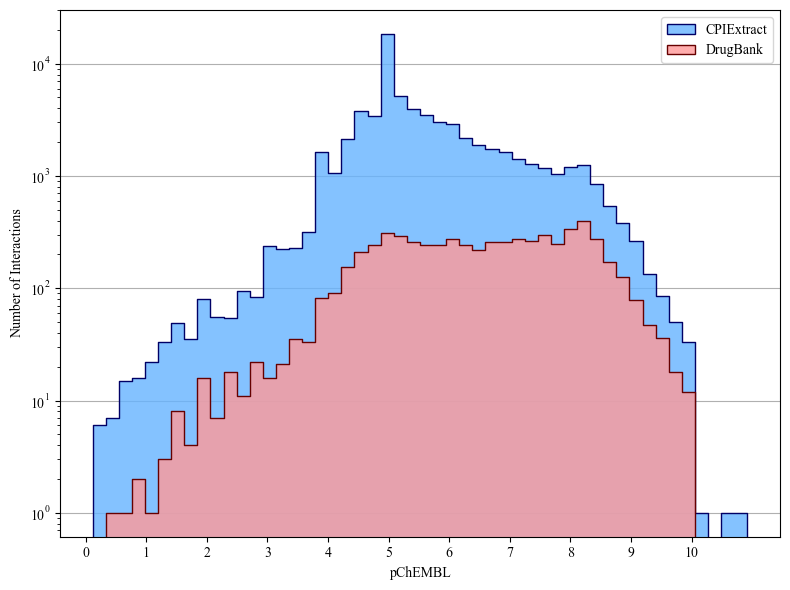

In [32]:
data = cpe.copy()

# Plot distribution of only data with available pChEMBL values
data['ave_pchembl'] = data['ave_pchembl'].replace('Sources do not provide activity data', np.inf).astype(float)
data['ave_pchembl']= data['ave_pchembl'].replace(np.inf, np.nan).dropna()

# Collect data into num_bins bins
num_bins = 50

# Calculate bin edges
bin_edges = np.linspace(data['ave_pchembl'].min(), data['ave_pchembl'].max(), num_bins + 1)

filt = data.loc[data['drugbank']==1]

colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(8, 6))
ax = sns.histplot(data=data['ave_pchembl'], element='step',
                  label='CPIExtract', kde=False, color=colors[1], bins=bin_edges, 
                  log_scale=[False, False], edgecolor='#000066', linewidth=1, alpha=0.8)
ax = sns.histplot(data=filt['ave_pchembl'], element='step',
                  label='DrugBank', kde=False, color=colors[0], bins=bin_edges, 
                  log_scale=[False, False], edgecolor='#660000', linewidth=1, alpha=0.8)
plt.yscale('log')

plt.xlabel('pChEMBL')
plt.ylabel('Number of Interactions')
plt.xticks(ticks=range(0, 11), labels=[str(i) for i in range(0, 11)])
plt.legend()
plt.tight_layout()
plt.show()

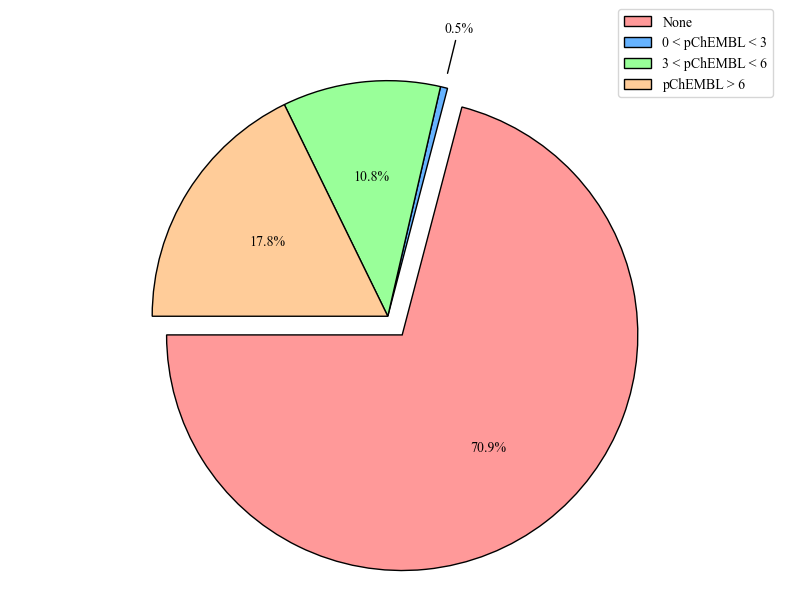

In [26]:
data = cpe.loc[cpe['drugbank']==1].copy()

# Plot distribution of only data with available pChEMBL values
data['ave_pchembl'] = data['ave_pchembl'].replace('Sources do not provide activity data', -1).astype(float)

palette = sns.color_palette("husl", 4)
# Define the number of bins
num_bins = [-2, 0, 3, 6, 15]

# Create bins based on the number of bins specified
data['bins'] = pd.cut(data['ave_pchembl'], bins=num_bins)
counts = data['bins'].value_counts().sort_index()
sns.set_palette("pastel")

explode = (0.1, 0, 0, 0)
# Add colors
def my_autopct(pct):
    return ('%.1f%%' % pct) if pct > 1 else ''
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
fig1, ax1 = plt.subplots(figsize=(8,6))
wedges, _, _ = ax1.pie(counts, explode=explode, labels=None, colors=colors, autopct=my_autopct,
        shadow=False, startangle=180, wedgeprops={'edgecolor': 'black'})
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')

label = '0 < pChEMBL < 3'
count = counts[1]
angle = (wedges[1].theta2 - wedges[1].theta1)/2. + wedges[1].theta1
r = 1.05 * wedges[1].r
x = r * np.cos(np.deg2rad(angle))
y = r * np.sin(np.deg2rad(angle))
ax1.annotate(f"{count/counts.sum()*100:.1f}%",
             xy=(x, y),
             xytext=(1.2*x, 1.2*y),
             ha='center', va='center',
             arrowprops=dict(arrowstyle="-", color='black', lw=1),
             fontsize=10, color='black')
plt.tight_layout()
plt.legend(labels=['None', '0 < pChEMBL < 3', '3 < pChEMBL < 6', 'pChEMBL > 6'], loc="upper right", bbox_to_anchor=(1, 1.1))
plt.show()

## Prot2Comp

In [33]:
# Aggregate and count occurrences for the 'input_id' column
densities = {}

clean = pce.loc[pce['ave_pchembl'] != 'Sources do not provide activity data']
clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)
for thresh in [6, 8]:
    counts = clean.loc[(clean['ave_pchembl'] > thresh), 'input_id'].value_counts()
    counts_df = counts.reset_index()
    counts_df.columns = ['input_id', 'counts']
    densities[f'CPIExtract pChEMBL > {thresh}'] = counts_df.counts
for thresh in [6, 8]:
    db = clean.loc[(clean['ave_pchembl'] > thresh) & (clean['drugbank'] == 1), 'input_id'].value_counts()
    counts_db = db.reset_index()
    counts_db.columns = ['input_id', 'counts']
    densities[f'DB pChEMBL > {thresh}'] = counts_db.counts


C:\Users\andre\AppData\Local\Temp\ipykernel_6020\3029116599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)


CPIExtract pChEMBL > 6: 595.4019495412844
CPIExtract pChEMBL > 8: 193.89256198347107
DB pChEMBL > 6: 5.4485842026825635
DB pChEMBL > 8: 3.3877551020408165


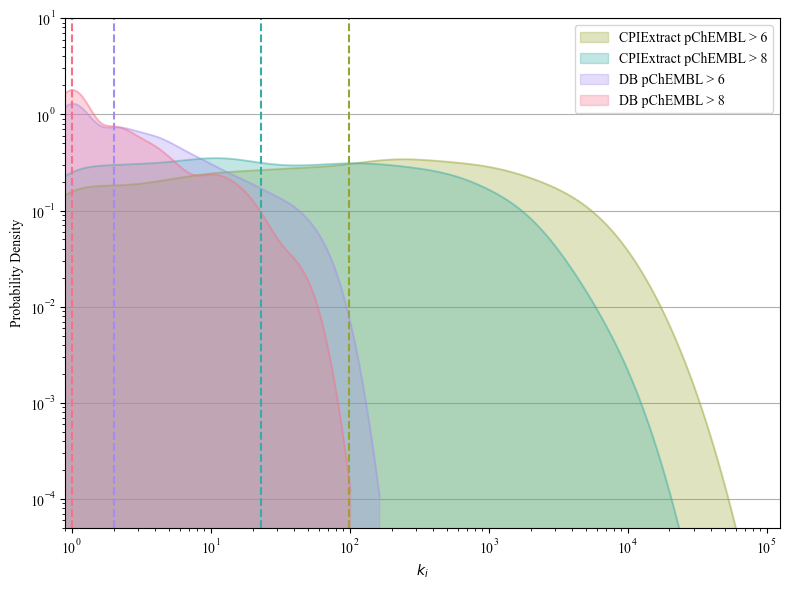

In [34]:
import matplotlib.patches as mpatches
# Initialize color palette
lenn = len(densities)
palette = sns.color_palette("husl", lenn)
plt.figure(figsize=(8,6))
# Plot KDE plots for each category in densities
for i, (label, data) in enumerate(densities.items()):
    kde = sns.kdeplot(data, label=label, alpha=0.3, fill=None, color=palette[(i+1)%lenn], log_scale=[True, True])
    
    x, y = kde.get_lines()[-1].get_data()
    # Use fill_between to fill the area under the curve
    plt.fill_between(x, y, 0.0000001, color=palette[(i+1)%lenn], alpha=0.3)
    
    # Calculate median
    median_value = data.median()
    
    print(f"{label}: {data.mean()}")
    line = '--'
    plt.axvline(x=median_value, linestyle=line, color=palette[(i+1)%lenn])

legend_handles = [mpatches.Patch(color=palette[(i + 1) % lenn], alpha=0.3, label=label) for i, label in enumerate(densities.keys())]

# Set labels and title
plt.xlabel('$k_i$')
plt.ylabel('Probability Density')
# Plot mean line
plt.xlim(0.9)
plt.ylim(5*10e-6, 10) 
# Show legend
plt.legend(handles=legend_handles)
plt.tight_layout()
# Show the plot
plt.show()

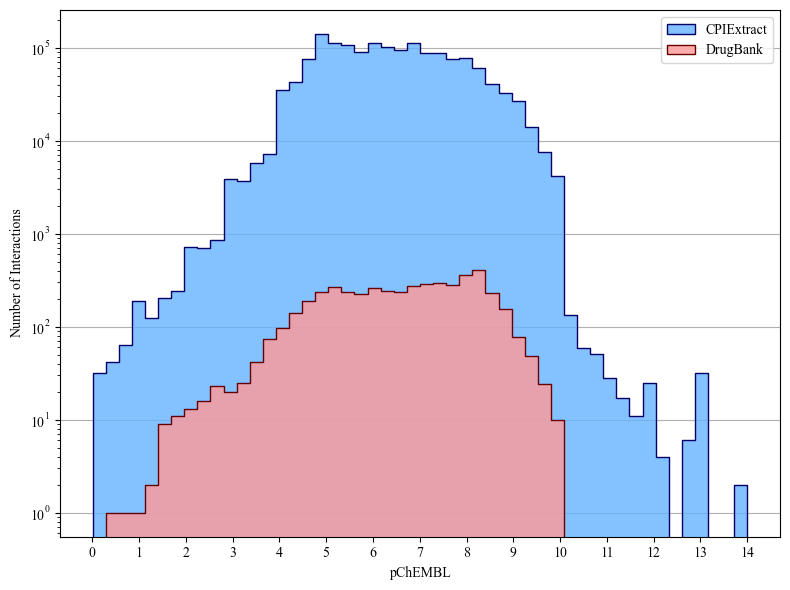

In [39]:
data = pce.copy()

# Plot distribution of only data with available pChEMBL values
data['ave_pchembl'] = data['ave_pchembl'].replace('Sources do not provide activity data', np.inf).astype(float)
data['ave_pchembl']= data['ave_pchembl'].replace(np.inf, np.nan)
data = data.dropna()
# Collect data into num_bins bins
num_bins = 50

# Calculate bin edges
bin_edges = np.linspace(data['ave_pchembl'].min(), data['ave_pchembl'].max(), num_bins + 1)

filt = data.loc[data['drugbank']==1]

colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(8, 6))
ax = sns.histplot(data=data['ave_pchembl'], label='CPIExtract', element='step',
                  kde=False, color=colors[1], bins=bin_edges, log_scale=[False, False], edgecolor='#000066', linewidth=1, alpha=0.8)
ax = sns.histplot(data=filt['ave_pchembl'], label='DrugBank', element='step',
                  kde=False, color=colors[0], bins=bin_edges, log_scale=[False, False], edgecolor='#660000', linewidth=1, alpha=0.8)
plt.yscale('log')

plt.xlabel('pChEMBL')
plt.ylabel('Number of Interactions')
plt.xticks(ticks=range(0, 15), labels=[str(i) for i in range(0, 15)])
plt.legend()
plt.tight_layout()
plt.show()

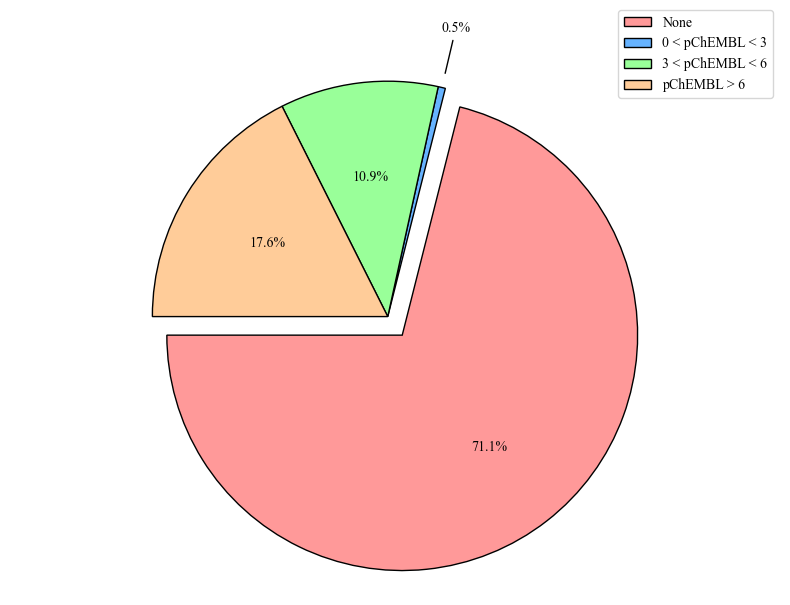

In [40]:
data = pce.loc[pce['drugbank']==1].copy()

# Plot distribution of only data with available pChEMBL values
data['ave_pchembl'] = data['ave_pchembl'].replace('Sources do not provide activity data', -1).astype(float)

palette = sns.color_palette("husl", 4)
# Define the number of bins
num_bins = [-2, 0, 3, 6, 15]

# Create bins based on the number of bins specified
data['bins'] = pd.cut(data['ave_pchembl'], bins=num_bins)
counts = data['bins'].value_counts().sort_index()
sns.set_palette("pastel")

explode = (0.1, 0, 0, 0)
# Add colors
def my_autopct(pct):
    return ('%.1f%%' % pct) if pct > 1 else ''
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
fig1, ax1 = plt.subplots(figsize=(8,6))
wedges, _, _ = ax1.pie(counts, explode=explode, labels=None, colors=colors, autopct=my_autopct,
        shadow=False, startangle=180, wedgeprops={'edgecolor': 'black'})
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')

# Add leader line and label for the first slice (0.1%)
label = '0 < pChEMBL < 3'
count = counts[1]
angle = (wedges[1].theta2 - wedges[1].theta1)/2. + wedges[1].theta1
r = 1.05 * wedges[1].r
x = r * np.cos(np.deg2rad(angle))
y = r * np.sin(np.deg2rad(angle))
ax1.annotate(f"{count/counts.sum()*100:.1f}%",
             xy=(x, y),
             xytext=(1.2*x, 1.2*y),
             ha='center', va='center',
             arrowprops=dict(arrowstyle="-", color='black', lw=1),
             fontsize=10, color='black')
plt.tight_layout()
plt.legend(labels=['None', '0 < pChEMBL < 3', '3 < pChEMBL < 6', 'pChEMBL > 6'], loc="upper right", bbox_to_anchor=(1, 1.1))
# plt.title('Percentage of interactions based on pChEMBL',pad=35)
plt.show()

# FooDB

In [74]:
# Aggregate and count occurrences for the 'compound_id' column
densities = {}

cleancpe = cpe.loc[cpe['ave_pchembl'] != 'Sources do not provide activity data']
cleancpe['ave_pchembl'] = cleancpe['ave_pchembl'].astype(float)

clean = foodb.loc[foodb['ave_pchembl'] != 'Sources do not provide activity data']
clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)
for thresh in [6, 8]:
    counts = cleancpe.loc[(cleancpe['ave_pchembl'] > thresh), 'DB_ID'].value_counts()
    counts_df = counts.reset_index()
    counts_df.columns = ['DB_ID', 'counts']
    densities[f'DrugBank drugs pChEMBL > {thresh}'] = counts_df.counts
    counts = clean.loc[(clean['ave_pchembl'] > thresh), 'inchi'].value_counts()
    counts_df = counts.reset_index()
    counts_df.columns = ['inchi', 'counts']
    densities[f'FooDB compounds pChEMBL >  {thresh}'] = counts_df.counts



C:\Users\andre\AppData\Local\Temp\ipykernel_6020\1269498899.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleancpe['ave_pchembl'] = cleancpe['ave_pchembl'].astype(float)
C:\Users\andre\AppData\Local\Temp\ipykernel_6020\1269498899.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean['ave_pchembl'] = clean['ave_pchembl'].astype(float)


DrugBank drugs pChEMBL > 6: 4.981051507872965
FooDB compounds pChEMBL >  6: 3.0
DrugBank drugs pChEMBL > 8: 2.366213151927438
FooDB compounds pChEMBL >  8: 1.5865384615384615


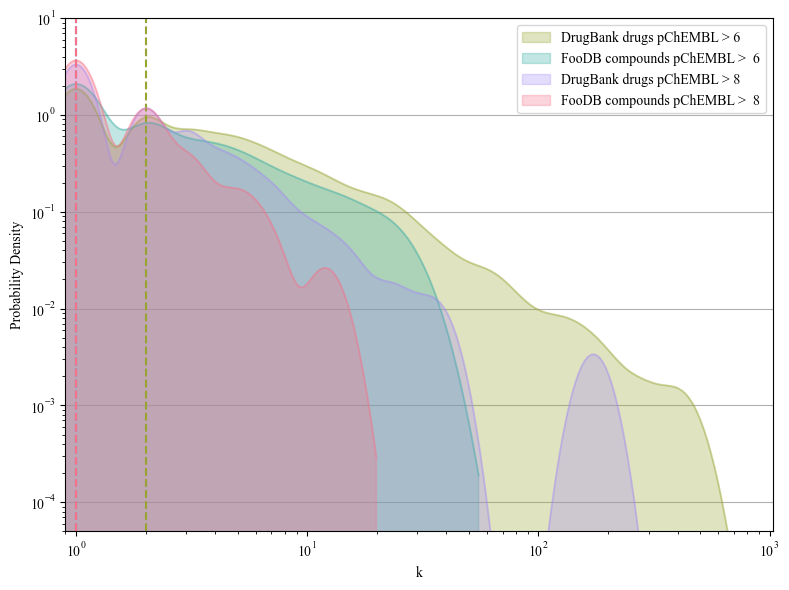

In [75]:
import matplotlib.patches as mpatches
# Initialize color palette
lenn = len(densities)
palette = sns.color_palette("husl", lenn)
plt.figure(figsize=(8,6))
# Plot KDE plots for each category in densities
for i, (label, data) in enumerate(densities.items()):

    kde = sns.kdeplot(data, label=label, alpha=0.3, fill=None, color=palette[(i+1)%lenn], log_scale=[True, True])
    
    x, y = kde.get_lines()[-1].get_data()
    # Use fill_between to fill the area under the curve
    plt.fill_between(x, y, 0.0000001, color=palette[(i+1)%lenn], alpha=0.3)

    if label[:2] != 'DB':
        line = '--'
    else:
        line = '-'
    # Calculate median
    median_value = data.median()
    
    print(f"{label}: {data.mean()}")
    plt.axvline(x=median_value, linestyle=line, color=palette[(i+1)%lenn])

legend_handles = [mpatches.Patch(color=palette[(i + 1) % lenn], alpha=0.3, label=label) for i, label in enumerate(densities.keys())]

plt.xlabel('k')
plt.ylabel('Probability Density')
# Plot mean line
plt.xlim(0.9)
plt.ylim(5*10e-6, 10)  
# Show legend
plt.legend(handles=legend_handles)
plt.tight_layout()
# Show the plot
plt.show()

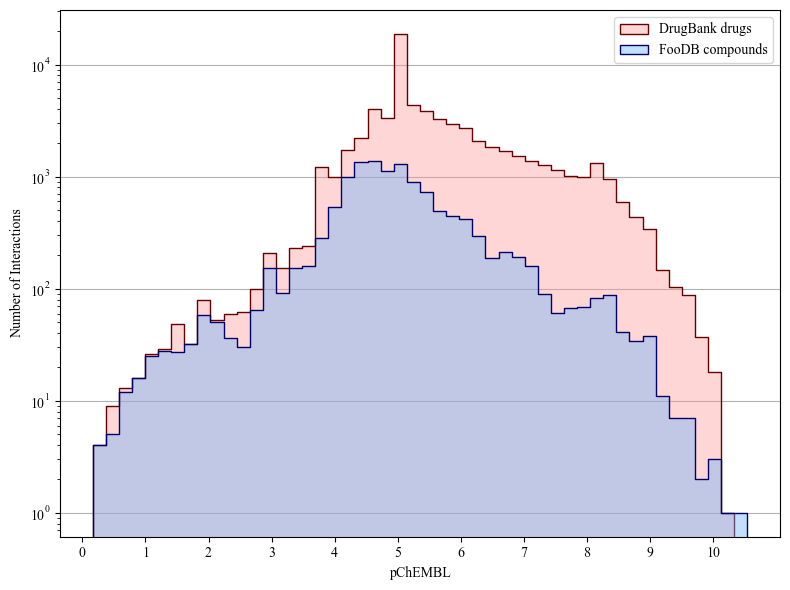

In [76]:
datacpe = cpe.copy()

# Plot distribution of only data with available pChEMBL values
datacpe['ave_pchembl'] = datacpe['ave_pchembl'].replace('Sources do not provide activity data', np.inf).astype(float)
datacpe['ave_pchembl']= datacpe['ave_pchembl'].replace(np.inf, np.nan).dropna()


data = foodb.copy()

# Plot distribution of only data with available pChEMBL values
data['ave_pchembl'] = data['ave_pchembl'].replace('Sources do not provide activity data', np.inf).astype(float)
data['ave_pchembl']= data['ave_pchembl'].replace(np.inf, np.nan).dropna()
# Collect data into num_bins bins
num_bins = 50

# Calculate bin edges
bin_edges = np.linspace(data['ave_pchembl'].min(), data['ave_pchembl'].max(), num_bins + 1)

colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(8, 6))
ax = sns.histplot(data=datacpe['ave_pchembl'], label='DrugBank drugs', element='step',
                  kde=False, color=colors[0], bins=bin_edges, log_scale=[False, False], edgecolor='#660000', linewidth=1, alpha=0.4)
ax = sns.histplot(data=data['ave_pchembl'], label='FooDB compounds', element='step',
                  kde=False, color=colors[1], bins=bin_edges, log_scale=[False, False], edgecolor='#000066', linewidth=1, alpha=0.4)
plt.yscale('log')

plt.xlabel('pChEMBL')
plt.ylabel('Number of Interactions')
plt.xticks(ticks=range(0, 11), labels=[str(i) for i in range(0, 11)])
plt.legend()
plt.tight_layout()
plt.show()

# Raw Count

## Comp2Prot

In [45]:
columns = ['pubchem', 'chembl', 'bindingdb', 'stitch',
       'ctd', 'dtc', 'otp', 'drugcentral', 'drugbank', 'DB_ID']

dat = cpe[columns]

# Melt the DataFrame to have a single column for sources
melted_df = pd.melt(dat, id_vars=['DB_ID'], var_name='Source', value_name='Interaction')

# Filter rows with interactions
interacting_sources = melted_df[melted_df['Interaction'] == 1]

# Group by Source and count unique compounds
source_counts = interacting_sources.groupby('Source')['DB_ID'].nunique().reset_index()

source_counts.rename(columns={'DB_ID': 'count'}, inplace=True)

source_ints = dat.drop(columns='DB_ID').sum()
source_ints = source_ints.reset_index()

source_ints.rename(columns={'index': 'source', 0:'count'}, inplace=True)
source_ints.sort_values(by='source', inplace=True)

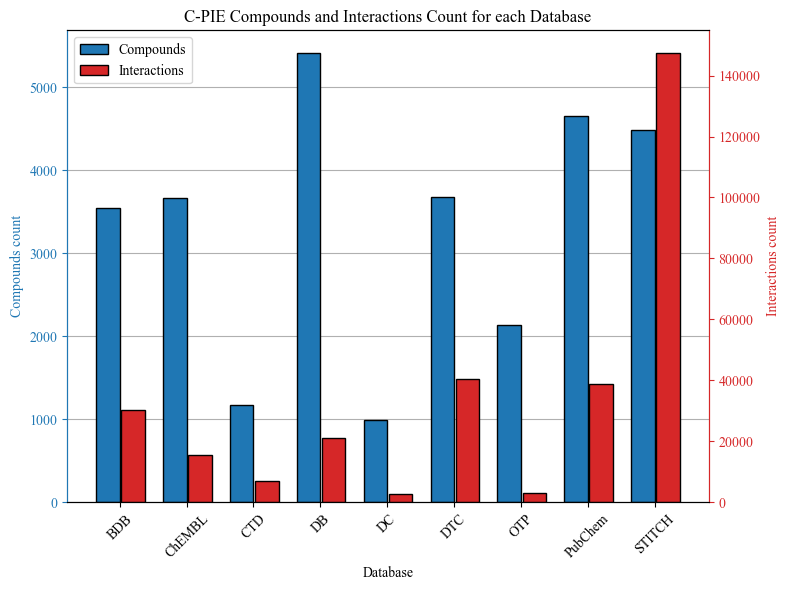

In [46]:
# Plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

# Define colors for interactions and compound count
interaction_color = 'skyblue'
compound_count_color = 'darkblue'

# Width of each bar
bar_width = 0.35
pal = sns.color_palette("tab10")
x = np.arange(len(source_counts['Source']))
# Plot interactions
bar1 = ax1.bar(x, source_counts['count'], width=bar_width, edgecolor='black', color=pal[0], label='Compounds')

# Set up secondary y-axis
ax2 = ax1.twinx()
ax2.grid(False)
# Plot compound count
bar2 = ax2.bar(x + bar_width + 0.025, source_ints['count'], width=bar_width, edgecolor='black',  color=pal[3], label='Interactions')

ax1.set_xticks(x + bar_width / 2)
ax1.set_xticklabels(['BDB', 'ChEMBL', 'CTD', 'DB', 'DC', 'DTC', 'OTP', 'PubChem', 'STITCH'], rotation=45)
ax1.spines['left'].set_color(pal[0])
ax1.tick_params(axis='y', colors=pal[0])
ax2.spines['left'].set_color(pal[0])

ax1.spines['right'].set_color(pal[3])
ax2.tick_params(axis='y', colors=pal[3])
ax2.spines['right'].set_color(pal[3])
# Set y-axis labels
ax1.set_ylabel('Compounds count', color=pal[0])
ax1.set_xlabel('Database')
ax2.set_ylabel('Interactions count', color=pal[3])
plt.title('C-PIE Compounds and Interactions Count for each Database')
bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax1.legend(bars, labels, loc='upper left')
plt.tight_layout()
plt.show()

with pchembl

In [47]:
columns = ['pubchem', 'chembl', 'bindingdb', 'stitch',
       'ctd', 'dtc', 'otp', 'drugcentral', 'drugbank', 'DB_ID', 'ave_pchembl']

dat = cpe[columns]

cols = ['PubChem', 'ChEMBL', 'BDB', 'STITCH', 'CTD', 'DTC', 'OTP', 'DC', 'DB', 'DB_ID', 'ave_pchembl']

dat.columns= cols
databases = pd.DataFrame()

for db in cols[:-2]:
    info = {}
    filt = dat[dat[db] == 1]
    info['Database'] = db
    if db not in ['STITCH','CTD', 'OTP', 'DB']:
        info['None'] = [len(filt[filt['ave_pchembl'] == 'Sources do not provide activity data'])]
        filt = filt[filt['ave_pchembl'] != 'Sources do not provide activity data']
        filt['ave_pchembl'] = filt['ave_pchembl'].astype(float)
        info['0 < pChEMBL < 3'] = [len(filt[filt['ave_pchembl'] < 3])]
        info['3 < pChEMBL < 6'] = [len(filt[filt['ave_pchembl'].between(3, 6, inclusive='left')])]
        info['pChEMBL > 6'] = [len(filt[filt['ave_pchembl'] >= 6])]  
    else:
        info['None'] = [len(filt)]
    databases = pd.concat([databases, pd.DataFrame.from_dict(info)])

databases = databases.sort_values('Database', ascending=False)
databases.set_index('Database', inplace=True)

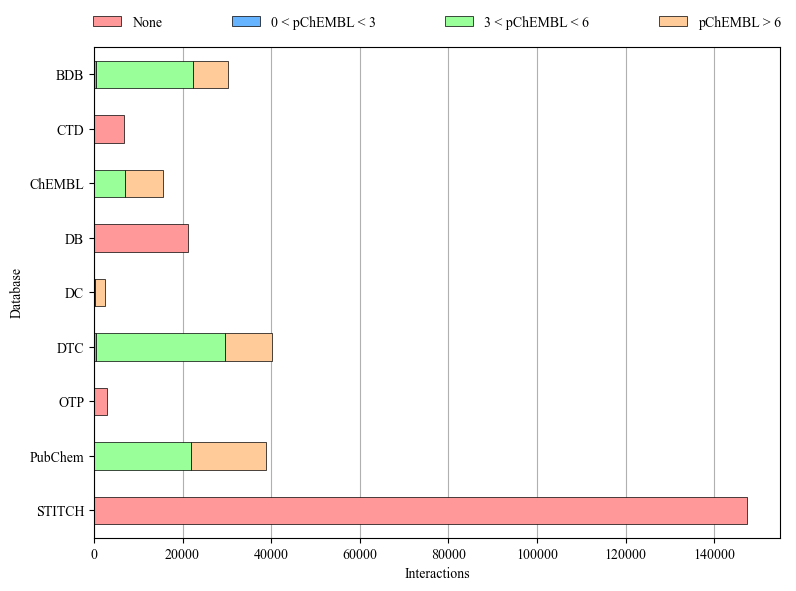

In [49]:
ax = databases.plot.barh(align='center', stacked=True, figsize=(8, 6), 
                                      color = ['#ff9999','#66b3ff','#99ff99','#ffcc99'], edgecolor='black', linewidth=0.5)
plt.grid(axis='y')
# plt.xscale('log')
legend = plt.legend(loc='center',
       frameon=False,
       bbox_to_anchor=(0., 1, 1., .102), 
       mode='expand', 
       ncol=4, 
       borderaxespad=-.46)
plt.xlabel('Interactions')
plt.tight_layout()

## Prot2Comp

In [50]:
columns = ['pubchem', 'chembl', 'bindingdb', 'stitch',
       'ctd', 'dtc', 'otp', 'drugcentral', 'drugbank', 'input_id']

dat = pce[columns]

# Melt the DataFrame to have a single column for sources
melted_df = pd.melt(dat, id_vars=['input_id'], var_name='Source', value_name='Interaction')

# Filter rows with interactions
interacting_sources = melted_df[melted_df['Interaction'] == 1]

# Group by Source and count unique compounds
source_counts = interacting_sources.groupby('Source')['input_id'].nunique().reset_index()

source_counts.rename(columns={'input_id': 'count'}, inplace=True)

source_ints = dat.drop(columns='input_id').sum()
source_ints = source_ints.reset_index()

source_ints.rename(columns={'index': 'source', 0:'count'}, inplace=True)
source_ints.sort_values(by='source', inplace=True)

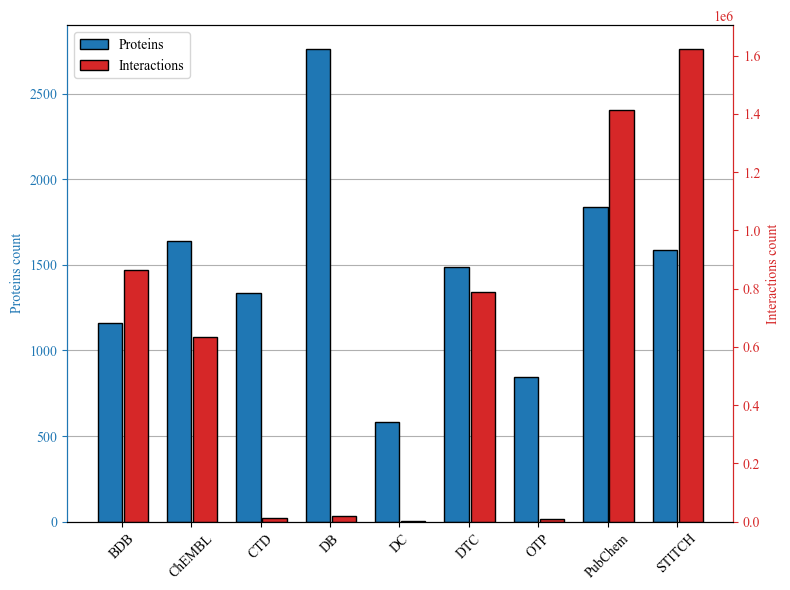

In [51]:
# Plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

# Define colors for interactions and compound count
interaction_color = 'skyblue'
compound_count_color = 'darkblue'

# Width of each bar
bar_width = 0.35
pal = sns.color_palette("tab10")
x = np.arange(len(source_counts['Source']))
# Plot interactions
bar1 = ax1.bar(x, source_counts['count'], width=bar_width, edgecolor='black', color=pal[0], label='Proteins')

# Set up secondary y-axis
ax2 = ax1.twinx()
ax2.grid(False)
# Plot compound count
bar2 = ax2.bar(x + bar_width + 0.025, source_ints['count'], width=bar_width, edgecolor='black',  color=pal[3], label='Interactions')

ax1.set_xticks(x + bar_width / 2)
ax1.set_xticklabels(['BDB', 'ChEMBL', 'CTD', 'DB', 'DC', 'DTC', 'OTP', 'PubChem', 'STITCH'], rotation=45)
ax1.spines['left'].set_color(pal[0])
ax1.tick_params(axis='y', colors=pal[0])
ax2.spines['left'].set_color(pal[0])

ax1.spines['right'].set_color(pal[3])
ax2.tick_params(axis='y', colors=pal[3])
ax2.spines['right'].set_color(pal[3])
# Set y-axis labels
ax1.set_ylabel('Proteins count', color=pal[0])
ax2.set_ylabel('Interactions count', color=pal[3])

bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax1.legend(bars, labels, loc='upper left')
plt.tight_layout()
plt.show()

# FooDB

In [52]:
columns = ['pubchem', 'chembl', 'bindingdb', 'stitch',
       'ctd', 'dtc', 'otp', 'drugcentral', 'drugbank', 'input_id']

dat = foodb[columns]

melted_df = pd.melt(dat, id_vars=['input_id'], var_name='Source', value_name='Interaction')

interacting_sources = melted_df[melted_df['Interaction'] == 1]

# Group by Source and count unique compounds
source_counts = interacting_sources.groupby('Source')['input_id'].nunique().reset_index()

source_counts.rename(columns={'input_id': 'count'}, inplace=True)

source_ints = dat.drop(columns='input_id').sum()
source_ints = source_ints.reset_index()

source_ints.rename(columns={'index': 'source', 0:'count'}, inplace=True)
source_ints.sort_values(by='source', inplace=True)

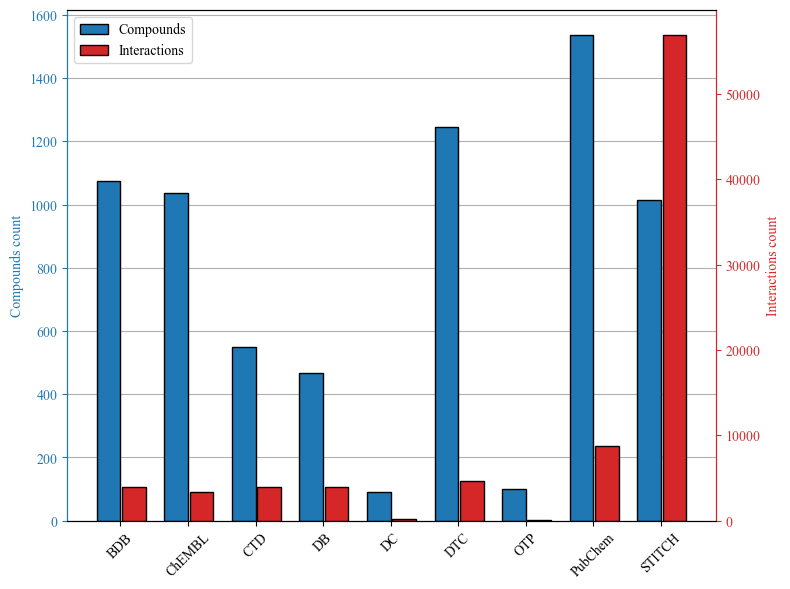

In [54]:
# Plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

# Define colors for interactions and compound count
interaction_color = 'skyblue'
compound_count_color = 'darkblue'

# Width of each bar
bar_width = 0.35
pal = sns.color_palette("tab10")
x = np.arange(len(source_counts['Source']))
# Plot interactions
bar1 = ax1.bar(x, source_counts['count'], width=bar_width, edgecolor='black', color=pal[0], label='Compounds')

# Set up secondary y-axis
ax2 = ax1.twinx()
ax2.grid(False)
# Plot compound count
bar2 = ax2.bar(x + bar_width + 0.025, source_ints['count'], width=bar_width, edgecolor='black',  color=pal[3], label='Interactions')

names = ['BDB', 'ChEMBL', 'CTD', 'DB', 'DC', 'DTC', 'OTP', 'PubChem', 'STITCH']
ax1.set_xticks(x + bar_width / 2)
ax1.set_xticklabels(names, rotation=45)
ax1.spines['left'].set_color(pal[0])
ax1.tick_params(axis='y', colors=pal[0])
ax2.spines['left'].set_color(pal[0])



ax1.spines['right'].set_color(pal[3])
ax2.tick_params(axis='y', colors=pal[3])
ax2.spines['right'].set_color(pal[3])
# Set y-axis labels
ax1.set_ylabel('Compounds count', color=pal[0])
ax2.set_ylabel('Interactions count', color=pal[3])

bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax1.legend(bars, labels, loc='upper left')
plt.tight_layout()
plt.show()

# Line and violin plots

## For DB candidates

In [55]:
tot = pd.read_csv('data/candidates.csv')
cand = tot[(tot['unique_count'] > 15) & (tot['unique_coverage'] > 0.8) & (tot['cct_percentage'] < 0.5)]
cand

,DB_ID,unique_count,total_count,drugbank_count,unique_coverage,cct_count,cct_percentage
0,DB01238,38,337,43,0.883721,5,0.116279
2,DB01224,25,187,30,0.833333,6,0.200000
3,DB00477,25,201,29,0.862069,7,0.241379
14,DB01200,18,65,20,0.900000,2,0.100000
18,DB08901,17,164,21,0.809524,6,0.285714
27,DB06637,16,18,18,0.888889,2,0.111111


### Degree ratio

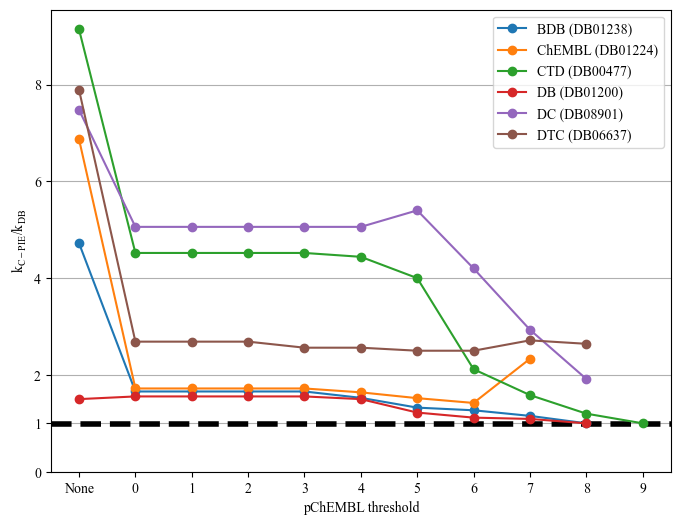

In [57]:
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
plt.figure(figsize=(8, 6))
plt.axhline(y=0.99, color='black', linestyle='--', lw=4)

for i, id in enumerate(cand['DB_ID']):
    data = cpe[(cpe['DB_ID'] == id)]   
    
    # Count interactions per compound
    drugbank = data.loc[data['drugbank'] == 1,'DB_ID'].value_counts().values[0]
    cpie = data['DB_ID'].value_counts().values[0]
    int_count_mean = [cpie/drugbank]
    max_t = 10
    dat = data[data['ave_pchembl'] != 'Sources do not provide activity data'].copy()
    dat['ave_pchembl'] = dat['ave_pchembl'].astype(float)
    for thresh in range(0, max_t):
        comps = dat.loc[dat['ave_pchembl'] >= thresh, 'DB_ID'].value_counts().values
        drugbank = dat.loc[(dat['drugbank'] == 1) & (dat['ave_pchembl'] >= thresh),'DB_ID'].value_counts().values
        if comps.size > 0:
            if drugbank.size > 0:
                int_count_mean.append(comps[0]/drugbank[0])
    line, = plt.plot(int_count_mean, marker='o', label=f'{names[i]} ({id})')

ts = ['None'] + [str(i) for i in range(max_t)]

# Set custom x-axis labels
plt.xticks(range(len(ts)), ts)
plt.yticks([0, 1] + list(range(2, 10, 2)))
# Add labels and title
plt.xlabel('pChEMBL threshold')
plt.ylabel('$k_{C-PIE}/k_{DB}$')
# Display the plot
plt.legend()
plt.show()

## Comp2Prot

In [62]:
c = {
    'DB00477': [],
    'DB08901': []
}
for id in c.keys():
    data = cpe[(cpe['DB_ID'] == id)]   
    
    # Count interactions per compound
    drugbank = data.loc[data['drugbank'] == 1,'DB_ID'].value_counts().values[0]
    # Store compound counts in the dictionary
    cpie = data['DB_ID'].value_counts().values[0]
    c[id].append(cpie/drugbank)
    max_t = 10
    dat = data[data['ave_pchembl'] != 'Sources do not provide activity data'].copy()
    dat['ave_pchembl'] = dat['ave_pchembl'].astype(float)
    for thresh in range(0, max_t):
        comps = dat.loc[dat['ave_pchembl'] >= thresh, 'DB_ID'].value_counts().values
        drugbank = dat.loc[(dat['drugbank'] == 1) & (dat['ave_pchembl'] >= thresh),'DB_ID'].value_counts().values
        if comps.size > 0:
            if drugbank.size > 0:
                c[id].append(comps[0]/drugbank[0])

C:\Users\andre\AppData\Local\Temp\ipykernel_6020\690823543.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['ave_pchembl']=dat['ave_pchembl'].astype(float)
C:\Users\andre\AppData\Local\Temp\ipykernel_6020\690823543.py:43: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=test, x='thresh', y='count', hue='thresh', alpha=0.7,
C:\Users\andre\AppData\Local\Temp\ipykernel_6020\690823543.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ts)


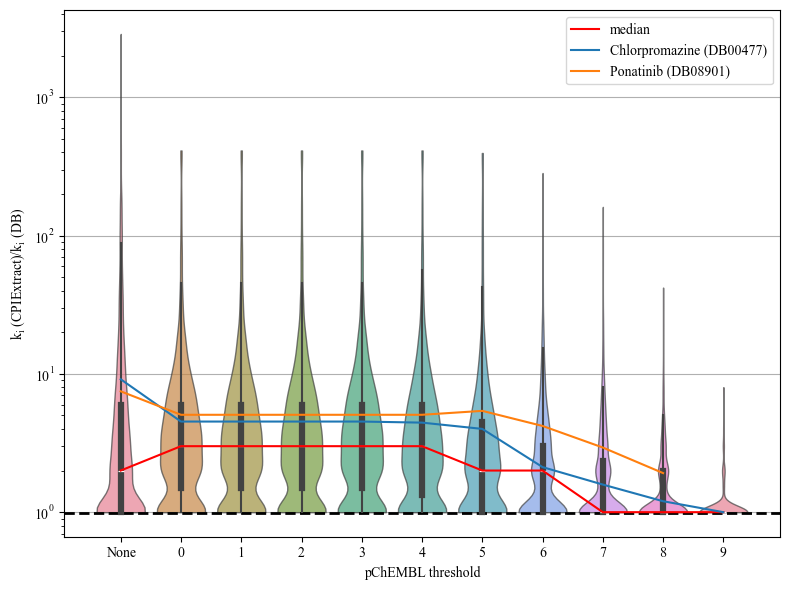

In [63]:
from matplotlib.patches import Patch

columns = ['bindingdb', 'chembl', 'ctd', 'drugbank', 'drugcentral', 'dtc', 'otp', 'stitch', 'pubchem', 'DB_ID']
dat = cpe[columns]
db_df = cpe[['DB_ID', 'ave_pchembl','drugbank']][cpe['drugbank'] == 1]
    
drugbank = db_df['DB_ID'].value_counts()
    
medians = []
cpie = dat['DB_ID'].value_counts()
test = pd.DataFrame()
frame = cpie.divide(drugbank, fill_value=0).replace([np.inf, -np.inf], np.nan).dropna().reset_index()
medians.append(frame['count'].median())
frame['thresh'] = 'None'
test = pd.concat([test, frame])
int_count = [frame]
max_t = 10
dat = cpe[cpe['ave_pchembl'] != 'Sources do not provide activity data']
dat['ave_pchembl']=dat['ave_pchembl'].astype(float)


db_df = db_df[db_df['ave_pchembl'] != 'Sources do not provide activity data']
db_df['ave_pchembl']=db_df['ave_pchembl'].astype(float)

ts = ['None'] + [str(i) for i in range(max_t)]

for i, thresh in enumerate(range(0, max_t)):
    comps = dat.loc[dat['ave_pchembl'] >= thresh, 'DB_ID'].value_counts()
    drugbank = db_df.loc[db_df['ave_pchembl'] >= thresh, 'DB_ID'].value_counts()
    frame = comps.divide(drugbank, fill_value=0).replace([np.inf, -np.inf], np.nan).dropna().reset_index()
    medians.append(frame['count'].median())
    frame['thresh'] = ts[i+1]

    int_count.append(frame)
    test = pd.concat([test, frame])

fig, ax = plt.subplots(figsize=(8, 6))

plt.axhline(y=0.99, color='black', linestyle='--', lw=2)
sns.violinplot(data=test, x='thresh', y='count', hue='thresh', alpha=0.7, 
               palette=sns.color_palette("husl", 10), log_scale=True, cut=0, linewidth=1)
ax.set_xticklabels(ts)
# Plot medians
plt.plot(medians, color='red', linewidth=1.5, label='median')
plt.plot(c['DB00477'], linewidth=1.5, label='Chlorpromazine (DB00477)')
plt.plot(c['DB08901'], linewidth=1.5, label='Ponatinib (DB08901)')

plt.xlabel('pChEMBL threshold')
plt.ylabel('$k_i$ (CPIExtract)/$k_i$ (DB)')

plt.tight_layout()
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Data1'),
    Patch(facecolor='darkblue', edgecolor='black', label='Data2')
]

plt.legend()
plt.show()

### Overlap Count

C:\Users\andre\AppData\Local\Temp\ipykernel_6020\4153704234.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['ave_pchembl']=dat['ave_pchembl'].astype(float)


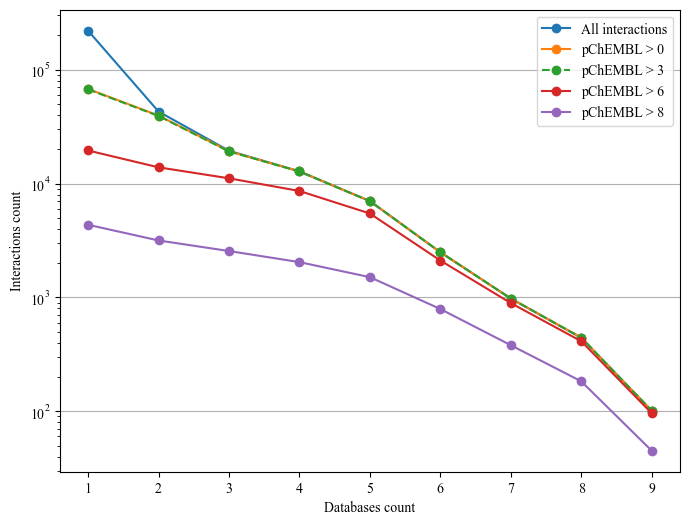

In [64]:
overlap = cpe[['src_count']].value_counts()
overlap = overlap.reset_index()
overlap.columns = ['sources', 'counts']
overlap = overlap.set_index('sources').sort_index()
o = list(overlap['counts'])
sums = [sum(o[i:]) for i in range(len(o))]

plt.figure(figsize=(8, 6))
plt.plot(sums, marker='o', label='All interactions', linestyle='-')
dat = cpe[cpe['ave_pchembl'] != 'Sources do not provide activity data']
dat['ave_pchembl']=dat['ave_pchembl'].astype(float)
for thresh in [0,3,6,8]:
    overlap = dat.loc[dat['ave_pchembl'] >= thresh, 'src_count'].value_counts().reset_index()
    overlap.columns = ['sources', 'counts']
    overlap = overlap.set_index('sources').sort_index()
    o = list(overlap['counts'])
    sums = [sum(o[i:]) for i in range(len(o))]
    if thresh == 3:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='--')
    else:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='-')
# Plot the line plot
plt.xlabel('Databases count')
plt.ylabel('Interactions count')
plt.yscale('log')
plt.xticks(range(9),[i for i in range(1,10)])
plt.legend()
plt.show()

## Prot2Comp

C:\Users\andre\AppData\Local\Temp\ipykernel_6020\3736181256.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['ave_pchembl']=dat['ave_pchembl'].astype(float)
C:\Users\andre\AppData\Local\Temp\ipykernel_6020\3736181256.py:41: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=test, x='thresh', y='count', hue='thresh', alpha=0.7,
C:\Users\andre\AppData\Local\Temp\ipykernel_6020\3736181256.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ts)


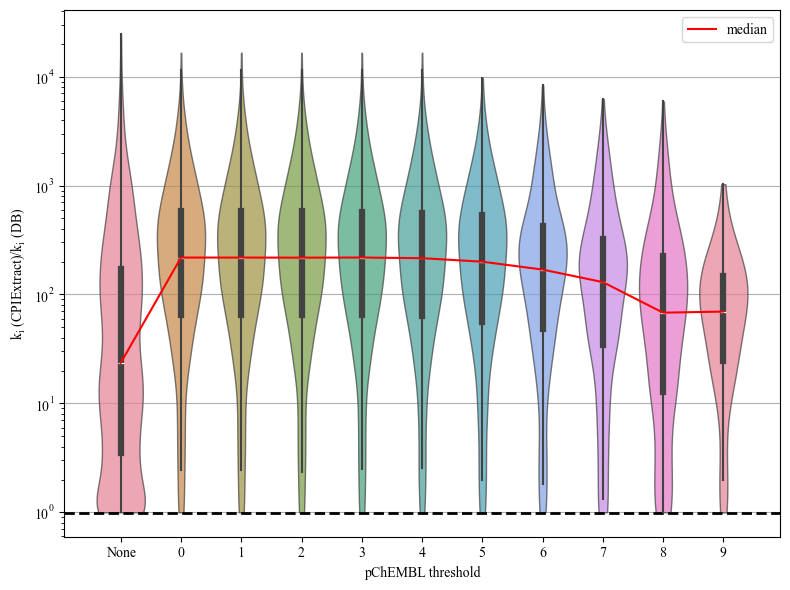

In [65]:
from matplotlib.patches import Patch

columns = ['bindingdb', 'chembl', 'ctd', 'drugbank', 'drugcentral', 'dtc', 'otp', 'stitch', 'pubchem', 'input_id']
dat = pce[columns]
db_df = pce[['input_id', 'ave_pchembl','drugbank']][pce['drugbank'] == 1]
    
drugbank = db_df['input_id'].value_counts()
    
medians = []
cpie = dat['input_id'].value_counts()
test = pd.DataFrame()
frame = cpie.divide(drugbank, fill_value=0).replace([np.inf, -np.inf], np.nan).dropna().reset_index()
medians.append(frame['count'].median())
frame['thresh'] = 'None'
test = pd.concat([test, frame])
int_count = [frame]
max_t = 10
dat = pce[pce['ave_pchembl'] != 'Sources do not provide activity data']
dat['ave_pchembl']=dat['ave_pchembl'].astype(float)


db_df = db_df[db_df['ave_pchembl'] != 'Sources do not provide activity data']
db_df['ave_pchembl']=db_df['ave_pchembl'].astype(float)

ts = ['None'] + [str(i) for i in range(max_t)]

for i, thresh in enumerate(range(0, max_t)):
    comps = dat.loc[dat['ave_pchembl'] >= thresh, 'input_id'].value_counts()
    drugbank = db_df.loc[db_df['ave_pchembl'] >= thresh, 'input_id'].value_counts()
    frame = comps.divide(drugbank, fill_value=0).replace([np.inf, -np.inf], np.nan).dropna().reset_index()
    medians.append(frame['count'].median())
    frame['thresh'] = ts[i+1]

    int_count.append(frame)
    test = pd.concat([test, frame])


fig, ax = plt.subplots(figsize=(8, 6))

plt.axhline(y=0.99, color='black', linestyle='--', lw=2)
sns.violinplot(data=test, x='thresh', y='count', hue='thresh', alpha=0.7, 
               palette=sns.color_palette("husl", 10), log_scale=True, cut=0, linewidth=1)
ax.set_xticklabels(ts)
# Plot medians
plt.plot(medians, color='red', linewidth=1.5, label='median')

plt.xlabel('pChEMBL threshold')
plt.ylabel('$k_i$ (CPIExtract)/$k_i$ (DB)')
plt.tight_layout()
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Data1'),
    Patch(facecolor='darkblue', edgecolor='black', label='Data2')
]

plt.legend()
plt.show()

### Overlap Count

C:\Users\andre\AppData\Local\Temp\ipykernel_6020\2495025867.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['ave_pchembl']=dat['ave_pchembl'].astype(float)


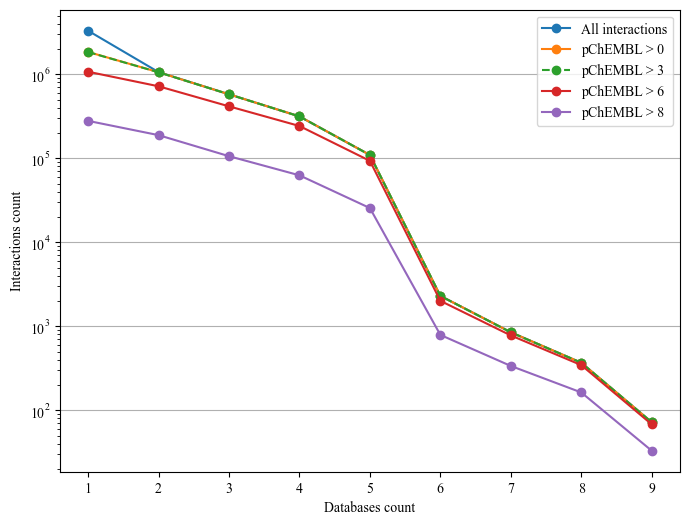

In [66]:
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

overlap = pce[['src_count']].value_counts()
overlap = overlap.reset_index()
overlap.columns = ['sources', 'counts']
overlap = overlap.set_index('sources').sort_index()
o = list(overlap['counts'])
sums = [sum(o[i:]) for i in range(len(o))]
plt.figure(figsize=(8, 6))
plt.plot(sums, marker='o', label='All interactions', linestyle='-')
dat = pce[pce['ave_pchembl'] != 'Sources do not provide activity data']
dat['ave_pchembl']=dat['ave_pchembl'].astype(float)
for thresh in [0,3,6,8]:
    overlap = dat.loc[dat['ave_pchembl'] >= thresh, 'src_count'].value_counts().reset_index()
    overlap.columns = ['sources', 'counts']
    overlap = overlap.set_index('sources').sort_index()
    o = list(overlap['counts'])
    sums = [sum(o[i:]) for i in range(len(o))]
    if thresh == 3:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='--')
    else:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='-')
# Plot the line plot

plt.xlabel('Databases count')
plt.ylabel('Interactions count')
plt.yscale('log')
plt.xticks(range(9),[i for i in range(1,10)])
plt.legend()
plt.show()

# FooDB

### Overlap Count

C:\Users\andre\AppData\Local\Temp\ipykernel_6020\2183336058.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['ave_pchembl']=dat['ave_pchembl'].astype(float)


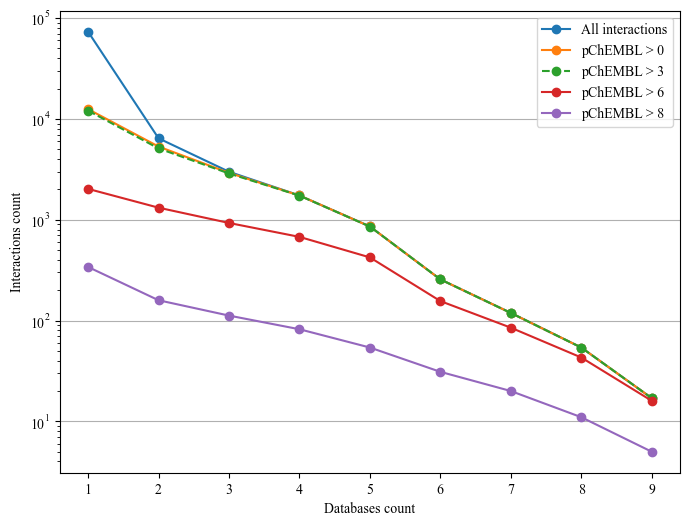

In [67]:
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

overlap = foodb[['src_count']].value_counts()
overlap = overlap.reset_index()
overlap.columns = ['sources', 'counts']
overlap = overlap.set_index('sources').sort_index()
o = list(overlap['counts'])
sums = [sum(o[i:]) for i in range(len(o))]

plt.figure(figsize=(8, 6))
plt.plot(sums, marker='o', label='All interactions', linestyle='-')
dat = foodb[foodb['ave_pchembl'] != 'Sources do not provide activity data']
dat['ave_pchembl']=dat['ave_pchembl'].astype(float)
for thresh in [0,3,6,8]:
    overlap = dat.loc[dat['ave_pchembl'] >= thresh, 'src_count'].value_counts().reset_index()
    overlap.columns = ['sources', 'counts']
    overlap = overlap.set_index('sources').sort_index()
    o = list(overlap['counts'])
    sums = [sum(o[i:]) for i in range(len(o))]
    if thresh == 3:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='--')
    else:
        plt.plot(sums, marker='o', label=f'pChEMBL > {thresh}', linestyle='-')
# Plot the line plot
plt.xlabel('Databases count')
plt.ylabel('Interactions count')
plt.yscale('log')
plt.xticks(range(9),[i for i in range(1,10)])
plt.legend()
plt.show()

# Candidates selection

In [68]:
pchembl = cpe[(cpe['drugbank'] == 1) & (cpe['pchembl_count'] >= 1)]

In [69]:
candidates = pchembl['DB_ID'].value_counts().reset_index().rename(columns={'count':'unique_count'})

In [70]:
db = pd.read_csv('data/DB.csv')
types = db[['drugbank-id','HGNC', 'protein_type']].dropna(subset=['HGNC']).drop_duplicates().rename(columns={'drugbank-id': 'DB_ID'})

In [72]:
# Unify gene identifiers  with biomart
from cpie.servers.BiomartServer import BiomartServer
ensembl = BiomartServer()

input_type='hgnc_id' 
attributes = ['hgnc_id', 'hgnc_symbol']
names = ['HGNC', 'hgnc_symbol']

input_ids = types['HGNC']

targets = ensembl.subset_search(input_type, input_ids, attributes, names)

In [77]:
new = types.merge(targets, on='HGNC', how='left')
new = new[['DB_ID', 'hgnc_symbol', 'protein_type']]
drugbank = cpe[cpe['drugbank'] == 1]
drugbank = drugbank.merge(new, on=['DB_ID', 'hgnc_symbol'],how='left')
# Count CYP, carriers and transporters interactions
cct = drugbank.loc[(drugbank['hgnc_symbol'].str.contains('CYP')) | drugbank['protein_type'].isin(['transporters', 'carriers']), 'DB_ID'].\
    value_counts().reset_index().rename(columns={'count':'cct_count'})

In [78]:
candidates2 = pchembl.groupby('DB_ID')['pchembl_count'].sum().sort_values(ascending=False).\
    reset_index().rename(columns={'pchembl_count':'total_count'})
res = pd.merge(candidates, candidates2, on='DB_ID')

In [79]:
tot = cpe.loc[(cpe['drugbank'] == 1), 'DB_ID'].value_counts().reset_index().rename(columns={'count':'drugbank_count'})
res = pd.merge(res, tot, on='DB_ID', how='left')

In [80]:
res = pd.merge(res, cct, on='DB_ID', how='left')

In [81]:
res['cct_count'] = res['cct_count'].fillna(0)
res['cct_percentage'] = res['cct_count']/res['drugbank_count']
res['unique_coverage'] = res['unique_count']/res['drugbank_count']

In [82]:
res

,DB_ID,unique_count,total_count,drugbank_count,cct_count,cct_percentage,unique_coverage
0,DB01238,38,337,43,4.0,0.093023,0.883721
1,DB00363,30,509,38,8.0,0.210526,0.789474
2,DB01224,25,187,30,5.0,0.166667,0.833333
3,DB00477,25,201,29,4.0,0.137931,0.862069
4,DB00246,23,159,31,1.0,0.032258,0.741935
...,...,...,...,...,...,...,...
2691,DB03749,1,2,1,0.0,0.000000,1.000000
2692,DB02840,1,2,1,0.0,0.000000,1.000000
2693,DB03807,1,2,1,0.0,0.000000,1.000000
2694,DB03183,1,2,1,0.0,0.000000,1.000000


In [60]:
res.to_csv('data/candidates.csv', index=False)